# Distributed Group Lasso Regression
## Parameter Definition and Centralized Optimization

The problem is defined as

$$
\min_{x \in \mathbb{R}^{12}} \quad \sum_{i=1}^{4}\|A_i x - b_i\|_2^2 + \lambda \sum_{g=1}^{4}\|x_g\|_2,
$$

where the decision variable is partitioned into four groups
$x=[x_1^\top,x_2^\top,x_3^\top,x_4^\top]^\top$ with $x_g\in\mathbb{R}^3$,
and the solution is denoted as $x^*$.

The network topology is a ring, and the gossip matrix is defined as $W = I - 0.2L$, with $L$ being the Laplacian matrix of the graph.

In [117]:
import numpy as np
import numpy.typing as npt

if __name__ == "__main__":
    # 4 nodes, 4 groups, each group has size 3
    from topolink import Graph, bootstrap

    L = np.array([[2, -1, 0, -1], [-1, 2, -1, 0], [0, -1, 2, -1], [-1, 0, -1, 2]])
    W = np.eye(4) - L * 0.2

    graph = Graph.from_mixing_matrix(W, transport="ipc")
    n_nodes = graph.number_of_nodes
    nodes = [str(i) for i in range(1, n_nodes + 1)]
    group_size = 3
    dim = n_nodes * group_size  # 12

    # Should be consistent with the definition in the graph server
    from topolink import Graph

    L = np.array([[2, -1, 0, -1], [-1, 2, -1, 0], [0, -1, 2, -1], [-1, 0, -1, 2]])
    W = np.eye(4) - L * 0.2

    graph = Graph.from_mixing_matrix(W, transport="ipc")
    nodes = [str(i) for i in range(1, n_nodes + 1)]

    import numpy.random as npr

    npr.seed(0)

    # ----- group structure -----
    groups = {
        "1": list(range(0, 3)),
        "2": list(range(3, 6)),
        "3": list(range(6, 9)),
        "4": list(range(9, 12)),
    }

    # ----- ground truth (group sparse) -----
    # only group 1 and group 3 are active
    x_tilde = np.zeros(dim)
    x_tilde[groups["1"]] = npr.normal(0.0, 1.0, group_size)
    x_tilde[groups["3"]] = npr.normal(0.0, 1.0, group_size)

    # ----- local data -----
    # each node holds A_i and b_i
    m = 20  # number of samples per node

    A = {i: npr.normal(0.0, 1.0, (m, dim)) / np.sqrt(m) for i in nodes}
    eps = {i: npr.normal(0.0, 0.05, m) for i in nodes}
    b = {i: A[i] @ x_tilde + eps[i] for i in nodes}

    # ----- centralized reference solution (group lasso) -----
    import cvxpy as cp

    x = cp.Variable(dim)

    lam = 5.0

    loss = cp.sum([cp.sum_squares(A[i] @ x - b[i]) for i in nodes])

    group_penalty = 0
    for i in nodes:
        idx = groups[i]
        group_penalty += cp.norm(x[idx], 2)

    prob = cp.Problem(cp.Minimize(loss + lam * group_penalty))
    prob.solve(solver=cp.ECOS)

    x_star: npt.NDArray[np.float64] = x.value  # type: ignore

    print("Groups:", groups)
    print("Optimal solution x*:", x_star)

Groups: {'1': [0, 1, 2], '2': [3, 4, 5], '3': [6, 7, 8], '4': [9, 10, 11]}
Optimal solution x*: [ 1.16416945e+00  1.21184673e-01  6.01122370e-01  7.44961549e-11
  6.24987191e-10  6.01113212e-10  1.86045801e+00  1.66380011e+00
 -7.00201015e-01  5.54424142e-10  3.53356467e-10 -7.91165912e-10]


## Benchmarking Distributed Optimization Algorithms

In this section, we benchmark the distributed optimization algorithms `EXTRA`, `NIDS`, `DIGing`, `AugDGM`, `WE`, and `RGT` on the ridge regression problem.
Each algorithm is executed with its respective step size, and their performance is compared in terms of mean squared error (MSE)

$$
\frac{1}{4d} \sum_{i = 1}^{4} || x_i - x^* ||^2
$$

over iterations, where $x_i, x^* \in \mathbb{R}^d$.

In [118]:
from multiprocessing import Pool


def ridge_regression(
    node_id: str,
    dimension: int,
    a_i: npt.NDArray[np.float64],
    b_i: npt.NDArray[np.float64],
    lam_i: float,
    group_i: list[int],
    gamma: float,
    optimizer_name: str,
    max_iter: int = 100,
) -> npt.NDArray[np.float64]:
    import numpy as np

    x_i = np.zeros((max_iter, dimension), dtype=np.float64)

    # Define loss function
    def f(var: npt.NDArray[np.float64]) -> np.float64:
        return np.sum((a_i @ var - b_i) ** 2)

    # Define node handle with transform that adds noise to the payload
    from topolink import NodeHandle

    nh = NodeHandle(node_id, transport="ipc")

    # Create optimizer and run iterations
    from dco import get_optimizer, GroupLasso

    reg = GroupLasso(lam=lam_i, groups=[group_i])

    optimizer = get_optimizer(optimizer_name)(f, nh, gamma, reg=reg)

    optimizer.init(x_i[0])

    for k in range(max_iter - 1):
        x_i[k + 1] = optimizer.step(x_i[k])

    return x_i


if __name__ == "__main__":
    step_sizes = {
        "EXTRA": 0.16,
        "NIDS": 0.21,
        "DIGing": 0.11,
        "AugDGM": 0.31,
        "WE": 0.17,
        "RGT": 0.11,
        "AtcWE": 0.2,
        "RAugDGM": 0.1,
    }

    local_histories: dict[str, list[npt.NDArray[np.float64]]] = {}

    with Pool(processes=n_nodes) as pool:
        for alg, gam in step_sizes.items():
            bootstrap(graph)

            tasks = [
                pool.apply_async(
                    ridge_regression,
                    args=(i, dim, A[i], b[i], lam, groups[i], gam, alg),
                )
                for i in nodes
            ]

            local_histories[alg] = [task.get() for task in tasks]

            print(f"Algorithm: {alg}, Step size: {gam}, Finished!")

Algorithm: EXTRA, Step size: 0.16, Finished!
Algorithm: NIDS, Step size: 0.21, Finished!
Algorithm: DIGing, Step size: 0.11, Finished!
Algorithm: AugDGM, Step size: 0.31, Finished!
Algorithm: WE, Step size: 0.17, Finished!
Algorithm: RGT, Step size: 0.11, Finished!
Algorithm: AtcWE, Step size: 0.2, Finished!
Algorithm: RAugDGM, Step size: 0.1, Finished!


## Plot results

### Global Matplotlib Plotting Parameters and Sensor Color Scheme

In [119]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from numpy import mean, stack

    plt.rcParams["text.usetex"] = True
    plt.rcParams["font.family"] = "serif"

    plt.rcParams.update(
        {
            "font.size": 14,
            "axes.titlesize": 16,
            "axes.labelsize": 16,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
            "legend.fontsize": 13,
        }
    )

### MSE for robust algorithms `RAugDGM`, `RGT`, `WE`, and `RGT`

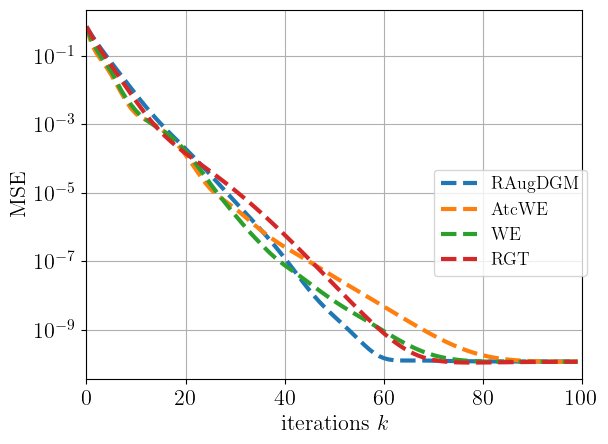

In [ ]:
if __name__ == "__main__":
    fig, ax = plt.subplots()

    line_options = {"linewidth": 3, "linestyle": "--"}

    hh: list[npt.NDArray[np.float64]] = []

    robust_algorithms = ["RAugDGM", "AtcWE", "WE", "RGT"]
    for alg in robust_algorithms:
        histories = local_histories[alg]
        # shape: (n_nodes, n_iter, dim)
        stacked_histories = stack(histories)
        # shape: (n_nodes, n_iter)
        mse_evolution_nodes = mean((stacked_histories - x_star) ** 2, axis=2)
        mse_evolution = mean(mse_evolution_nodes, axis=0)
        ax.semilogy(mse_evolution, label=alg, **line_options)
        hh.append(mse_evolution)

    ax.set_xlim((0, 100))
    ax.set_xlabel("iterations $k$")
    ax.set_ylabel("MSE")
    ax.legend(loc=(0.7, 0.28))
    ax.grid(True, which="major", linestyle="-", linewidth=0.8)

### MSE for `RAugDGM` and non-robust algorithms `EXTRA`, `AugDGM`, `NIDS`, and `DIGing`

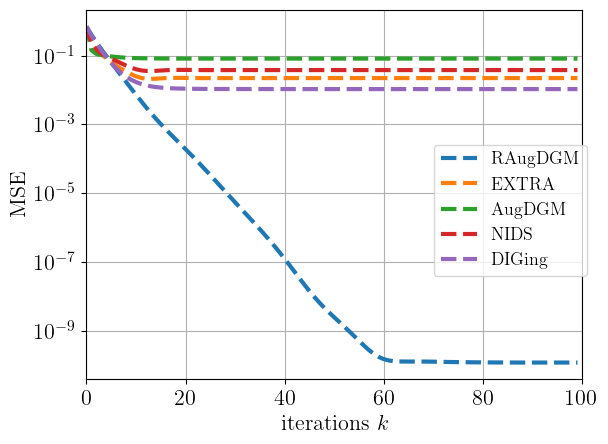

In [ ]:
if __name__ == "__main__":
    fig, ax = plt.subplots()

    line_options = {"linewidth": 3, "linestyle": "--"}

    hh: list[npt.NDArray[np.float64]] = []

    nonrobust_algorithms = ["RAugDGM", "EXTRA", "AugDGM", "NIDS", "DIGing"]
    for alg in nonrobust_algorithms:
        histories = local_histories[alg]
        # shape: (n_nodes, n_iter, dim)
        stacked_histories = stack(histories)
        # shape: (n_nodes, n_iter)
        mse_evolution_nodes = mean((stacked_histories - x_star) ** 2, axis=2)
        mse_evolution = mean(mse_evolution_nodes, axis=0)
        ax.semilogy(mse_evolution, label=alg, **line_options)
        hh.append(mse_evolution)

    ax.set_xlim((0, 100))
    ax.set_xlabel("iterations $k$")
    ax.set_ylabel("MSE")
    ax.legend(loc=(0.7, 0.28))
    ax.grid(True, which="major", linestyle="-", linewidth=0.8)